岭回归 vs 普通最小二乘
特征之间的相关性: 0.993

最小二乘系数: [1.79151496 1.2794498 ]

岭回归系数:
  λ =  0.0: [1.78170059 1.28886624]
  λ =  0.1: [1.71785732 1.34902159]
  λ =  1.0: [1.56854967 1.45976717]
  λ = 10.0: [1.35214833 1.33356296]
  λ = 100.0: [0.63196029 0.62780725]


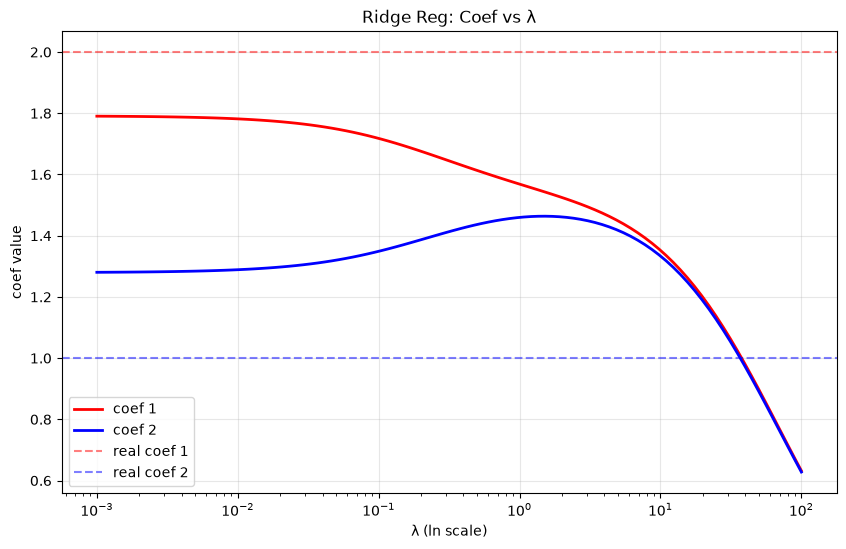


最优 λ (交叉验证): 0.7565
最优岭回归系数: [1.58607313 1.45268411]
普通最小二乘系数: [1.79151496 1.2794498 ]
真实系数: [2 1]


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ---- 创建有共线性的数据 ----
np.random.seed(42)
n_samples = 50
n_features = 2

# 两个高度相关的特征
X = np.random.randn(n_samples, n_features)
X[:, 1] = X[:, 0] + 0.1 * np.random.randn(n_samples)  # 高度相关！

# 真实系数
true_coef = np.array([2, 1])
y = X @ true_coef + 0.5 * np.random.randn(n_samples)

print("=" * 60)
print("岭回归 vs 普通最小二乘")
print("=" * 60)
print(f"特征之间的相关性: {np.corrcoef(X[:, 0], X[:, 1])[0, 1]:.3f}")

# ---- 普通最小二乘 ----
x_ols = np.linalg.lstsq(X, y, rcond=None)[0]
print(f"\n最小二乘系数: {x_ols}")

# ---- 岭回归 ----
lambdas = [0.01, 0.1, 1, 10, 100]
print("\n岭回归系数:")
for lam in lambdas:
    ATA_reg = X.T @ X + lam * np.eye(n_features)
    x_ridge = np.linalg.solve(ATA_reg, X.T @ y)
    print(f"  λ = {lam:4.1f}: {x_ridge}")

# ---- 系数随 λ 的变化 ----
lambdas_plot = np.logspace(-3, 2, 100)
coefs_ridge = []

for lam in lambdas_plot:
    ATA_reg = X.T @ X + lam * np.eye(n_features)
    x_ridge = np.linalg.solve(ATA_reg, X.T @ y)
    coefs_ridge.append(x_ridge)

coefs_ridge = np.array(coefs_ridge)

plt.figure(figsize=(10, 6))
# plt.semilogx(lambdas_plot, coefs_ridge[:, 0], 'r-', linewidth=2, label='系数1')
plt.semilogx(lambdas_plot, coefs_ridge[:, 0], 'r-', linewidth=2, label='coef 1')
# plt.semilogx(lambdas_plot, coefs_ridge[:, 1], 'b-', linewidth=2, label='系数2')
plt.semilogx(lambdas_plot, coefs_ridge[:, 1], 'b-', linewidth=2, label='coef 2')
# plt.axhline(y=true_coef[0], color='red', linestyle='--', alpha=0.5, label='真实系数1')
plt.axhline(y=true_coef[0], color='red', linestyle='--', alpha=0.5, label='real coef 1')
# plt.axhline(y=true_coef[1], color='blue', linestyle='--', alpha=0.5, label='真实系数2')
plt.axhline(y=true_coef[1], color='blue', linestyle='--', alpha=0.5, label='real coef 2')
# plt.xlabel('λ (对数尺度)')
plt.xlabel('λ (ln scale)')
# plt.ylabel('系数值')
plt.ylabel('coef value')
# plt.title('岭回归：系数随 λ 的变化')
plt.title('Ridge Reg: Coef vs λ')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ---- 岭回归的最优 λ：交叉验证 ----
from sklearn.linear_model import RidgeCV
ridge_cv = RidgeCV(alphas=lambdas_plot, scoring='neg_mean_squared_error')
ridge_cv.fit(X, y)
print(f"\n最优 λ (交叉验证): {ridge_cv.alpha_:.4f}")

# 用最优 λ 的模型
x_ridge_opt = np.linalg.solve(X.T @ X + ridge_cv.alpha_ * np.eye(n_features), X.T @ y)
print(f"最优岭回归系数: {x_ridge_opt}")
print(f"普通最小二乘系数: {x_ols}")
print(f"真实系数: {true_coef}")